Steady state temperature=300.18K


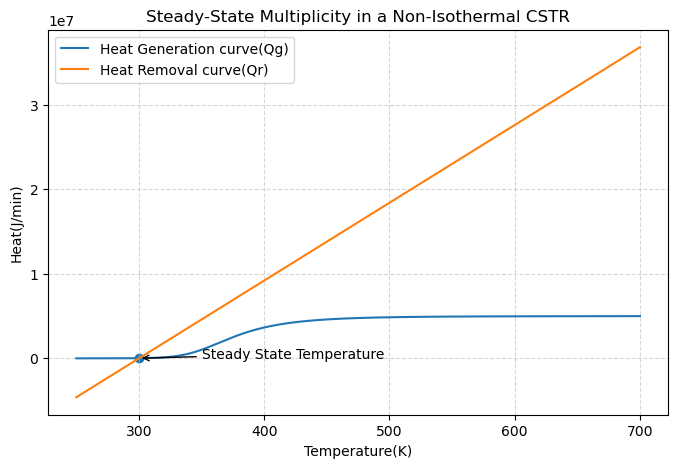

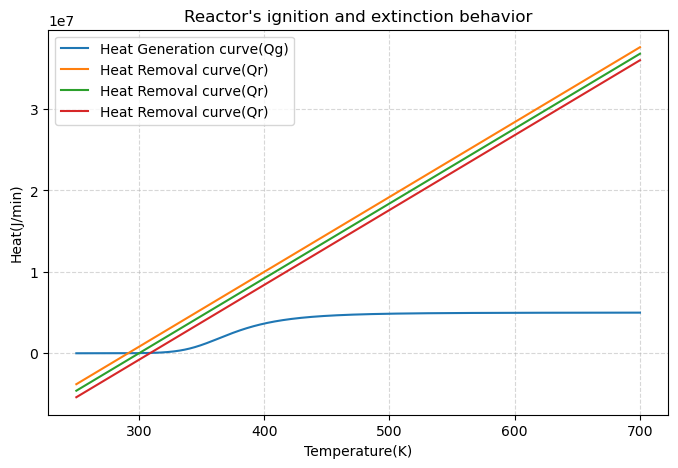

In [16]:
##Mini Project
##Steady-State Multiplicity in a Non-Isothermal CSTR
##Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
##Given Data
UA=8E4 #J/min·K
F=100 #mol/min
Cp=120 #J/mol·K
Tc=300 #K
CA0=2 #mol/L
Tin=300 #K
A=7E10 #1/min
Ea=80000 #J/mol
ΔH=-50000 #J/mol
R=8.314 #J/molK
V=100 #L
#Calculating Volumetric Flow rate and space time
nu=F/CA0 #L/min
tau=V/nu #min
def arrhenius(T):
    k=A*np.exp(-Ea/(R*T))
    return k
def Calculate_CA(T):
    k=arrhenius(T)
    #Solving quadratic:k*tau*CA^2+CA-CA0=0 (CSTR Mole balance FA0-FA+rAV=0)
    CA=(-1+np.sqrt(1+4*k*tau*CA0))/(2*k*tau)
    return CA
def reaction_rate(T):
    CA=Calculate_CA(T)
    rA=-arrhenius(T)*CA**2
    return rA
def Heat_Generation(T):
    rA=reaction_rate(T)
    Qg=-rA*-ΔH*V
    return Qg
def Heat_Removal(T):
    Qr=UA*(T-Tc)+F*Cp*(T-Tin)
    return Qr
Temps=np.linspace(250,700,1000)
plt.figure(figsize=(8,5))
plt.plot(Temps,Heat_Generation(Temps),label='Heat Generation curve(Qg)')
plt.plot(Temps,Heat_Removal(Temps),label='Heat Removal curve(Qr)')
plt.xlabel('Temperature(K)')
plt.ylabel('Heat(J/min)')
plt.title('Steady-State Multiplicity in a Non-Isothermal CSTR')
plt.grid(True,linestyle='--',alpha=0.5)
initial_guesses=[280,320,360,420,520,650]
def balance(T):
    Hg=Heat_Generation(T)
    Hr=Heat_Removal(T)
    return Hg-Hr
Steady_State_Temps=set()
for Temperatures in initial_guesses:
    Ans=fsolve(balance,Temperatures)
    Steady_State_Temps.add(np.round(Ans[0],2))
for temps in Steady_State_Temps:
    plt.scatter(temps,Heat_Removal(temps))
    plt.annotate('Steady State Temperature',xy=(temps,Heat_Removal(temps)),
    xytext=(temps+50,Heat_Removal(temps)*1.05),
    arrowprops=dict(
        facecolor='red',     
        arrowstyle='->'
    ))
    print(f'Steady state temperature={temps}K')
plt.legend()
plt.show()
Tc_vary=[290,300,310]
fig,ax=plt.subplots(figsize=(8,5))
ax.plot(Temps,Heat_Generation(Temps),label='Heat Generation curve(Qg)')
for Temperatures in Tc_vary:
    def Heat_Removal(T):
        Qr=UA*(T-Temperatures)+F*Cp*(T-Tin)
        return Qr
    ax.plot(Temps,Heat_Removal(Temps),label='Heat Removal curve(Qr) for ')
    ax.set_xlabel('Temperature(K)')
    ax.set_ylabel('Heat(J/min)')
    ax.set_title("Reactor's ignition and extinction behavior")
    ax.grid(True,linestyle='--',alpha=0.5)
plt.legend()
plt.show()
    